# Indian Banking - Python Analysis
same 100K customer dataset, this time using pandas and some charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('customers_100k.csv')

# convert date columns
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['created_date'] = pd.to_datetime(df['created_date'])
df['last_transaction_date'] = pd.to_datetime(df['last_transaction_date'])

# calculate age
df['age'] = (pd.Timestamp.now() - df['date_of_birth']).dt.days // 365

print(f'loaded {len(df):,} rows')
df.shape

loaded 100,000 rows


(100000, 25)

In [2]:
df.head()

,customer_id,bank_id,bank_name,account_number,title,first_name,middle_name,last_name,full_name,gender,...,annual_income,primary_source_of_funds,account_type,account_balance,credit_score,account_status,created_date,last_transaction_date,transactions_per_month,age
0,CUST28908766,SBI001,State Bank of India,29224648600,Mrs.,Kavita,Dev,Malhotra,Kavita Dev Malhotra,Female,...,841544,Salary,Savings,392560.75,446,Active,2025-12-31,2026-01-31,109,42
1,CUST93976837,SBI001,State Bank of India,872609870255,Dr.,Preeti,Kumar,Yadav,Preeti Kumar Yadav,Female,...,185570,Salary,Salary,298793.38,652,Inactive,2016-10-14,2025-10-13,122,63
2,CUST39266156,CBI001,Central Bank of India,330010008120,Dr.,Sunita,Rani,Jain,Sunita Rani Jain,Female,...,1127813,Business Income,Current,766680.71,360,Active,2025-02-18,2026-01-14,64,37
3,CUST61096350,SBI001,State Bank of India,909606912618,Dr.,Sakshi,NaN,Bansal,Sakshi Bansal,Female,...,381580,Salary,Salary,53665.10,414,Inactive,2025-06-19,2025-09-20,5,58
4,CUST93007229,CBI001,Central Bank of India,738125078625,Mr.,Aryan,Dev,Mishra,Aryan Dev Mishra,Male,...,1130529,Professional Income,Savings,372526.73,785,Active,2019-03-10,2025-12-08,51,30


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   customer_id              100000 non-null  str           
 1   bank_id                  100000 non-null  str           
 2   bank_name                100000 non-null  str           
 3   account_number           100000 non-null  int64         
 4   title                    100000 non-null  str           
 5   first_name               100000 non-null  str           
 6   middle_name              69922 non-null   str           
 7   last_name                100000 non-null  str           
 8   full_name                100000 non-null  str           
 9   gender                   100000 non-null  str           
 10  date_of_birth            100000 non-null  datetime64[us]
 11  email                    100000 non-null  str           
 12  phone                    100

In [4]:
df.describe()

,account_number,date_of_birth,phone,annual_income,account_balance,credit_score,created_date,last_transaction_date,transactions_per_month,age
count,1.000000e+05,100000,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,100000,100000,100000.000000,100000.000000
mean,4.996744e+11,1980-06-03 00:16:37.920000,9.184990e+11,1.065267e+06,1.307177e+06,599.845310,2021-03-01 16:31:32.447999,2025-10-17 17:40:32.736000,77.565200,45.319820
min,1.404084e+07,1945-01-04 00:00:00,9.170001e+11,0.000000e+00,5.037380e+03,300.000000,2016-03-06 00:00:00,2024-03-04 00:00:00,5.000000,17.000000
25%,2.484915e+11,1969-10-01 00:00:00,9.177468e+11,4.308202e+05,3.058244e+05,450.000000,2018-09-04 00:00:00,2025-11-29 00:00:00,41.000000,35.000000
50%,5.007556e+11,1980-06-01 00:00:00,9.185001e+11,7.293275e+05,8.205597e+05,600.000000,2021-03-01 00:00:00,2026-01-02 00:00:00,77.000000,45.000000
75%,7.506944e+11,1991-03-05 00:00:00,9.192548e+11,1.224492e+06,1.844491e+06,750.000000,2023-08-28 00:00:00,2026-02-02 00:00:00,114.000000,56.000000
max,9.999799e+11,2008-12-30 00:00:00,9.200000e+11,9.994447e+06,4.999922e+06,900.000000,2026-03-03 00:00:00,2026-03-03 00:00:00,150.000000,81.000000
std,2.893954e+11,NaN,8.681865e+08,1.202475e+06,1.308174e+06,173.257101,NaN,NaN,42.119622,12.685078


In [5]:
# checking nulls
df.isnull().sum()

customer_id                    0
bank_id                        0
bank_name                      0
account_number                 0
title                          0
first_name                     0
middle_name                30078
last_name                      0
full_name                      0
gender                         0
date_of_birth                  0
email                          0
phone                          0
address                        0
occupation                     0
annual_income                  0
primary_source_of_funds        0
account_type                   0
account_balance                0
credit_score                   0
account_status                 0
created_date                   0
last_transaction_date          0
transactions_per_month         0
age                            0
dtype: int64

## demographics

gender
Male      50006
Female    49994
Name: count, dtype: int64



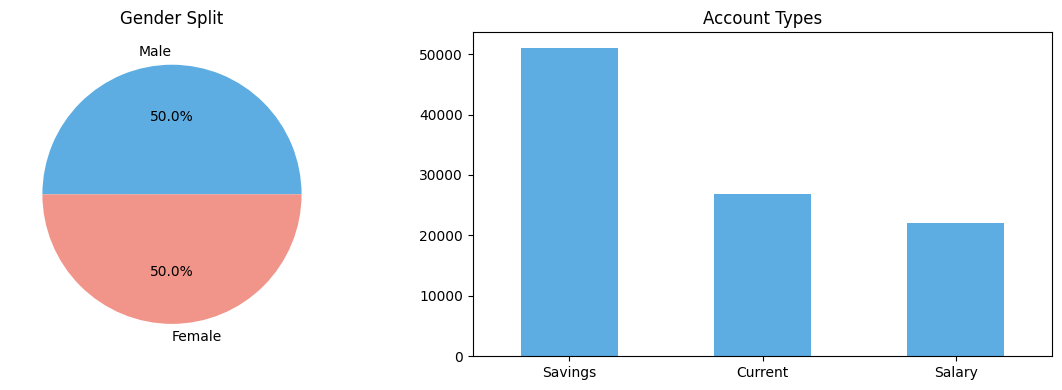

In [6]:
# gender split
print(df['gender'].value_counts())
print()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[0], colors=['#5dade2', '#f1948a'])
ax[0].set_ylabel('')
ax[0].set_title('Gender Split')

# account type breakdown
df['account_type'].value_counts().plot.bar(ax=ax[1], color='#5dade2')
ax[1].set_title('Account Types')
ax[1].set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# gender x account type
pd.crosstab(df['gender'], df['account_type'])

account_type,Current,Salary,Savings
gender,,,
Female,13438,11022,25534
Male,13371,11113,25522


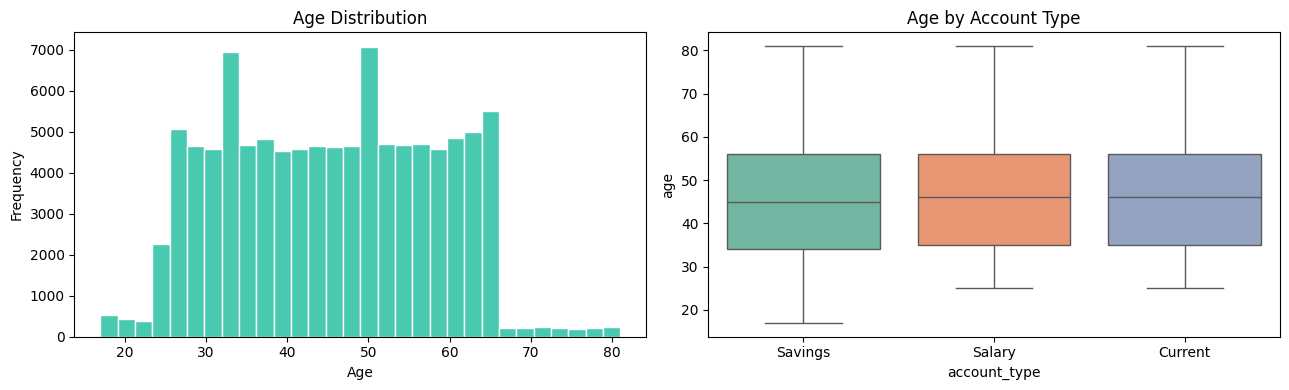

account_type
Current    45.8
Salary     45.9
Savings    44.8
Name: age, dtype: float64

In [8]:
# age distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df['age'].plot.hist(bins=30, ax=ax[0], color='#48c9b0', edgecolor='white')
ax[0].set_title('Age Distribution')
ax[0].set_xlabel('Age')

sns.boxplot(data=df, x='account_type', y='age', ax=ax[1], palette='Set2')
ax[1].set_title('Age by Account Type')

plt.tight_layout()
plt.show()

# avg age
df.groupby('account_type')['age'].mean().round(1)

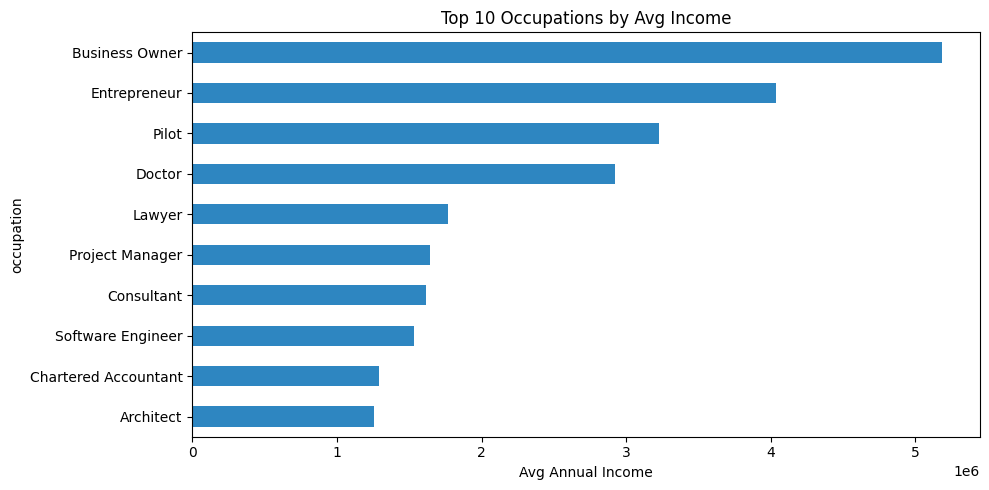

In [9]:
# top 10 occupations by avg income
top_occ = df.groupby('occupation')['annual_income'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 5))
top_occ.plot.barh(color='#2e86c1')
plt.title('Top 10 Occupations by Avg Income')
plt.xlabel('Avg Annual Income')
plt.tight_layout()
plt.show()

gender is almost 50-50. savings is the most popular account type. business owners and entrepreneurs earn way more than everyone else. age is spread pretty evenly between 20-70.

## balance & segmentation

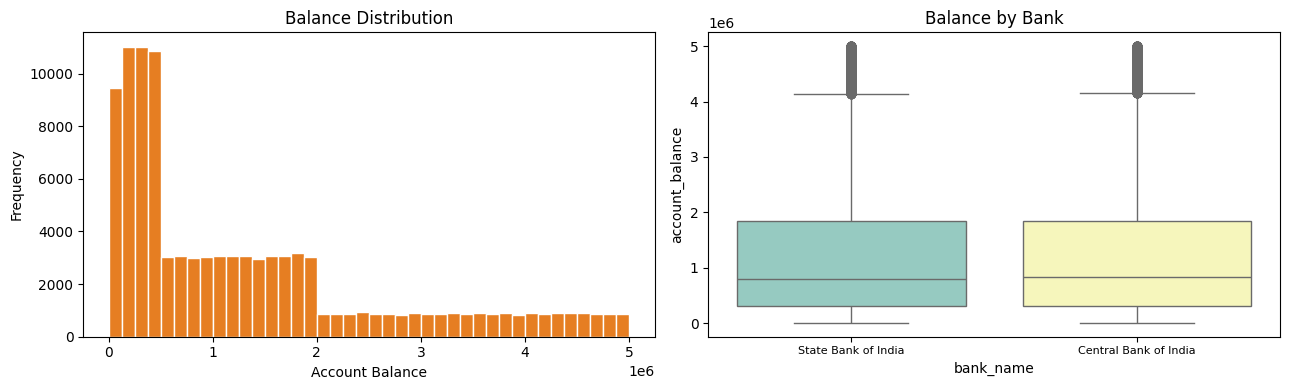

avg balance per bank:


bank_name
Central Bank of India    1309986.0
State Bank of India      1304366.0
Name: account_balance, dtype: float64

In [10]:
# balance distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df['account_balance'].plot.hist(bins=40, ax=ax[0], color='#e67e22', edgecolor='white')
ax[0].set_title('Balance Distribution')
ax[0].set_xlabel('Account Balance')

sns.boxplot(data=df, x='bank_name', y='account_balance', ax=ax[1], palette='Set3')
ax[1].set_title('Balance by Bank')
ax[1].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

print('avg balance per bank:')
df.groupby('bank_name')['account_balance'].mean().round(0)

In [11]:
# lets segment customers

def get_bal_seg(x):
    if x < 50000:
        return 'Low (<50K)'
    elif x <= 200000:
        return 'Medium (50K-2L)'
    else:
        return 'High (>2L)'

def get_credit_seg(x):
    if x >= 750:
        return 'Excellent'
    elif x >= 650:
        return 'Good'
    elif x >= 550:
        return 'Average'
    else:
        return 'Poor'

df['bal_seg'] = df['account_balance'].apply(get_bal_seg)
df['credit_cat'] = df['credit_score'].apply(get_credit_seg)

# cross tab
seg_table = pd.crosstab(df['bal_seg'], df['credit_cat'])
seg_table

credit_cat,Average,Excellent,Good,Poor
bal_seg,,,,
High (>2L),14046,21087,14157,34946
Low (<50K),477,734,463,1173
Medium (50K-2L),2169,3204,2141,5403


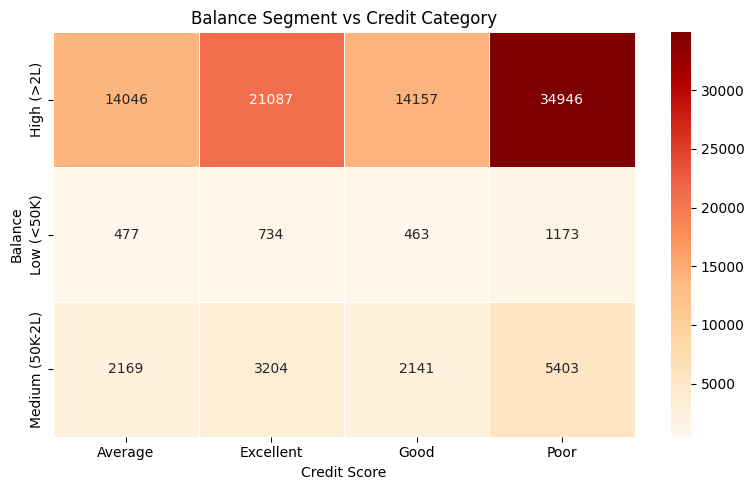

In [12]:
# heatmap of the segmentation - this is the most interesting chart imo
plt.figure(figsize=(8, 5))
sns.heatmap(seg_table, annot=True, fmt='d', cmap='OrRd', linewidths=0.5)
plt.title('Balance Segment vs Credit Category')
plt.ylabel('Balance')
plt.xlabel('Credit Score')
plt.tight_layout()
plt.show()

In [13]:
# what % of customers are high value?
high_val_pct = (df['account_balance'] > 200000).mean() * 100
print(f'high value customers (>2L): {high_val_pct:.1f}%')

# per bank
df.groupby('bank_name').apply(lambda x: round((x['account_balance'] > 200000).mean() * 100, 1))

high value customers (>2L): 84.2%


bank_name
Central Bank of India    84.2
State Bank of India      84.3
dtype: float64

that heatmap tells the whole story — the biggest cell is high balance + poor credit. 84% are high value which sounds great but the credit quality is not good.

## transactions

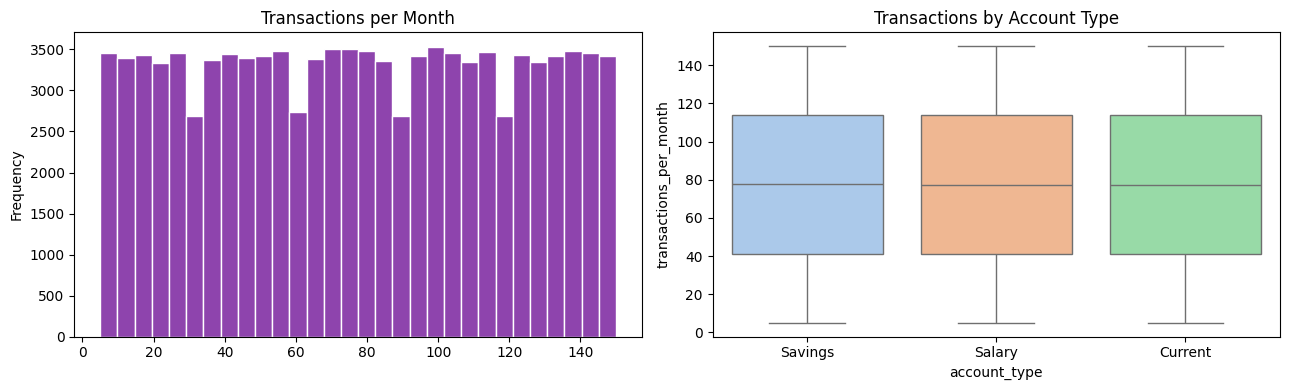

account_type
Current    77.4
Salary     77.4
Savings    77.7
Name: transactions_per_month, dtype: float64

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df['transactions_per_month'].plot.hist(bins=30, ax=ax[0], color='#8e44ad', edgecolor='white')
ax[0].set_title('Transactions per Month')

sns.boxplot(data=df, x='account_type', y='transactions_per_month', ax=ax[1], palette='pastel')
ax[1].set_title('Transactions by Account Type')

plt.tight_layout()
plt.show()

df.groupby('account_type')['transactions_per_month'].mean().round(1)

In [15]:
# inactive accounts
from datetime import timedelta

today = pd.Timestamp.now()
inactive_1yr = df[df['last_transaction_date'] < today - timedelta(days=365)]
inactive_6mo = df[df['last_transaction_date'] < today - timedelta(days=180)]

print(f'inactive > 1 year:  {len(inactive_1yr):,} ({len(inactive_1yr)/len(df)*100:.1f}%)')
print(f'inactive > 6 months: {len(inactive_6mo):,} ({len(inactive_6mo)/len(df)*100:.1f}%)')
print()
print('by bank (1yr+):')
print(inactive_1yr['bank_name'].value_counts())

inactive > 1 year:  14,930 (14.9%)
inactive > 6 months: 22,182 (22.2%)

by bank (1yr+):
bank_name
Central Bank of India    7503
State Bank of India      7427
Name: count, dtype: int64


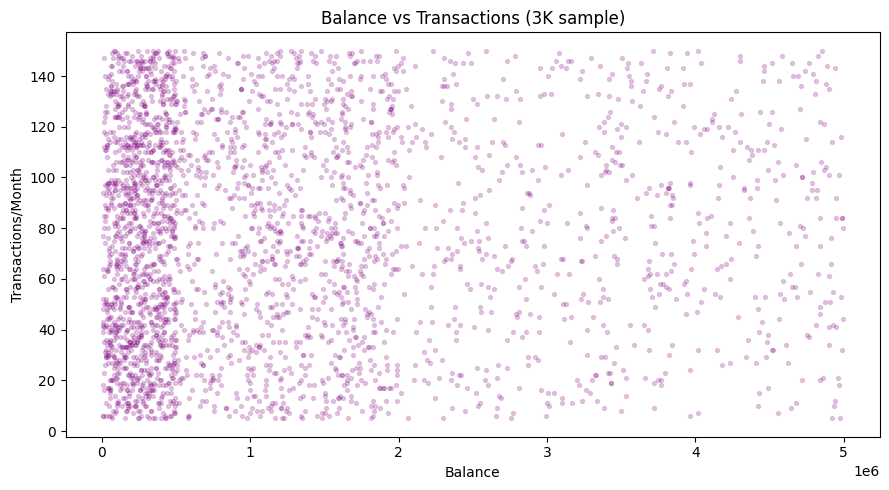

correlation: 0.004


In [16]:
# is there any relation between balance and transactions?
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(9, 5))
plt.scatter(sample['account_balance'], sample['transactions_per_month'], alpha=0.2, s=8, c='purple')
plt.title('Balance vs Transactions (3K sample)')
plt.xlabel('Balance')
plt.ylabel('Transactions/Month')
plt.tight_layout()
plt.show()

# doesnt look like theres any correlation
print(f'correlation: {df["account_balance"].corr(df["transactions_per_month"]):.3f}')

~77 transactions/month on avg regardless of account type. about 15% accounts are inactive for 1yr+. and no, balance and transactions are not correlated at all.

## credit scores

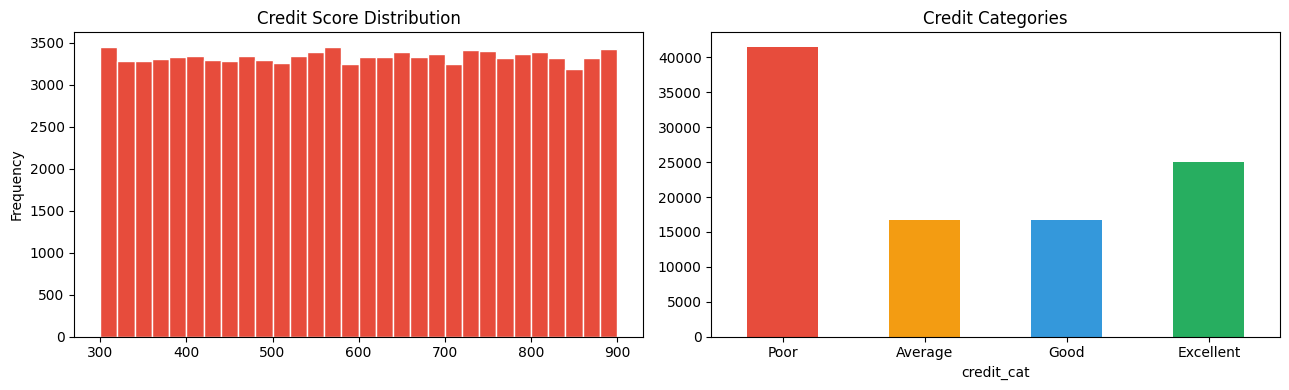

credit_cat
Poor         41522
Average      16692
Good         16761
Excellent    25025
Name: count, dtype: int64


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df['credit_score'].plot.hist(bins=30, ax=ax[0], color='#e74c3c', edgecolor='white')
ax[0].set_title('Credit Score Distribution')

order = ['Poor', 'Average', 'Good', 'Excellent']
colors = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
counts = df['credit_cat'].value_counts().reindex(order)
counts.plot.bar(ax=ax[1], color=colors)
ax[1].set_title('Credit Categories')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print(counts)

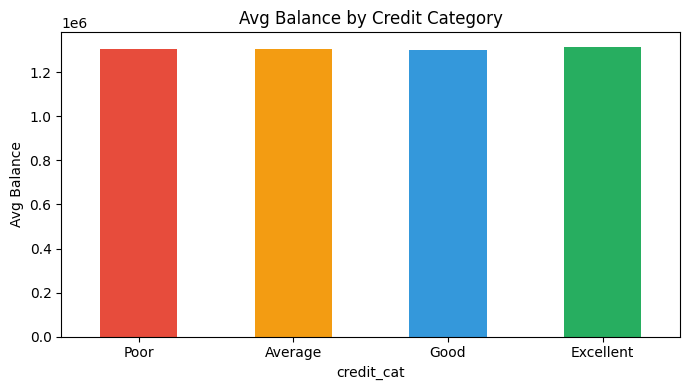

In [18]:
# avg balance per credit category
credit_bal = df.groupby('credit_cat')['account_balance'].mean().reindex(order)

plt.figure(figsize=(7, 4))
credit_bal.plot.bar(color=colors)
plt.title('Avg Balance by Credit Category')
plt.ylabel('Avg Balance')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# poor credit by bank
poor = df[df['credit_score'] < 550]
print(f'total poor credit customers: {len(poor):,}')
print()
poor['bank_name'].value_counts()

total poor credit customers: 41,522



bank_name
Central Bank of India    20804
State Bank of India      20718
Name: count, dtype: int64

41% poor credit is honestly alarming. and the balance doesnt really change much across credit categories which is weird — you'd expect better credit = higher balance but thats not the case here.

## income

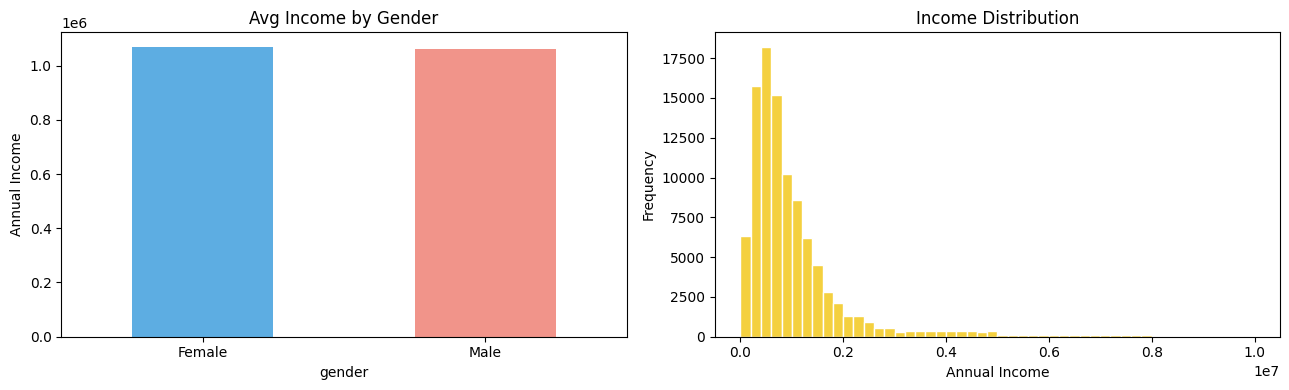

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('gender')['annual_income'].mean().plot.bar(ax=ax[0], color=['#5dade2', '#f1948a'])
ax[0].set_title('Avg Income by Gender')
ax[0].set_ylabel('Annual Income')
plt.sca(ax[0])
plt.xticks(rotation=0)

df['annual_income'].plot.hist(bins=50, ax=ax[1], color='#f4d03f', edgecolor='white')
ax[1].set_title('Income Distribution')
ax[1].set_xlabel('Annual Income')

plt.tight_layout()
plt.show()

In [21]:
print('avg income by bank:')
print(df.groupby('bank_name')['annual_income'].mean().round(0))
print()
print('most common occupations:')
print(df['occupation'].value_counts().head(10))

avg income by bank:
bank_name
Central Bank of India    1068580.0
State Bank of India      1061951.0
Name: annual_income, dtype: float64

most common occupations:
occupation
Plumber                2399
Pilot                  2387
Project Manager        2353
Driver                 2342
Chef                   2335
Insurance Agent        2330
Government Employee    2327
HR Manager             2327
Entrepreneur           2315
Content Writer         2310
Name: count, dtype: int64


income is balanced across genders. the distribution is right-skewed — most people earn under 20L but theres a long tail of high earners pulling the average up.

## risk & status

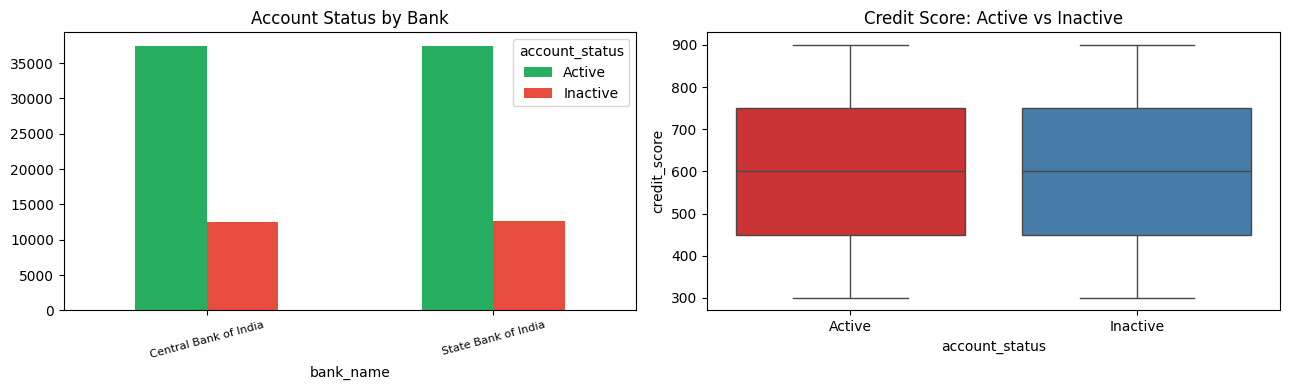

avg credit by status:


account_status
Active      599.7
Inactive    600.2
Name: credit_score, dtype: float64

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# active vs inactive per bank
status = pd.crosstab(df['bank_name'], df['account_status'])
status.plot.bar(ax=ax[0], color=['#27ae60', '#e74c3c'])
ax[0].set_title('Account Status by Bank')
ax[0].tick_params(axis='x', rotation=15, labelsize=8)

# credit score active vs inactive
sns.boxplot(data=df, x='account_status', y='credit_score', ax=ax[1], palette='Set1')
ax[1].set_title('Credit Score: Active vs Inactive')

plt.tight_layout()
plt.show()

print('avg credit by status:')
df.groupby('account_status')['credit_score'].mean().round(1)

high risk customers (poor credit + balance > 1L): 38,649
thats 38.6% of total

bank_name
Central Bank of India    19343
State Bank of India      19306
Name: count, dtype: int64


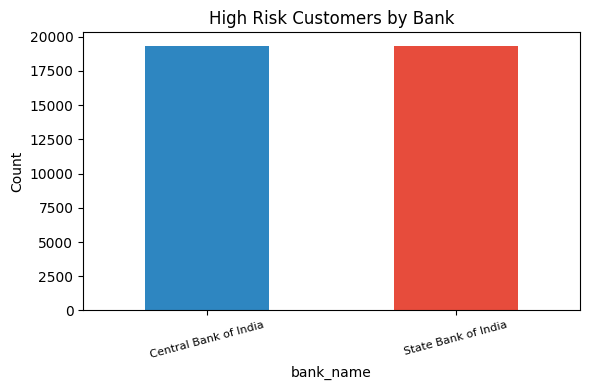

In [23]:
# the risky ones — high balance but poor credit
risky = df[(df['credit_score'] < 550) & (df['account_balance'] > 100000)]
print(f'high risk customers (poor credit + balance > 1L): {len(risky):,}')
print(f'thats {len(risky)/len(df)*100:.1f}% of total')
print()
print(risky['bank_name'].value_counts())

plt.figure(figsize=(6, 4))
risky['bank_name'].value_counts().plot.bar(color=['#2e86c1', '#e74c3c'])
plt.title('High Risk Customers by Bank')
plt.ylabel('Count')
plt.xticks(rotation=15, fontsize=8)
plt.tight_layout()
plt.show()

risk is split evenly between both banks. inactive accounts have slightly lower credit scores.

## bank comparison & trends

In [24]:
# overall bank comparison
bank_comp = df.groupby('bank_name').agg(
    customers=('customer_id', 'count'),
    avg_balance=('account_balance', 'mean'),
    avg_income=('annual_income', 'mean'),
    avg_credit=('credit_score', 'mean'),
    avg_txn=('transactions_per_month', 'mean'),
    total_deposits=('account_balance', 'sum')
).round(0)

bank_comp

,customers,avg_balance,avg_income,avg_credit,avg_txn,total_deposits
bank_name,,,,,,
Central Bank of India,50021,1309986.0,1068580.0,599.0,78.0,6.552683e+10
State Bank of India,49979,1304366.0,1061951.0,600.0,78.0,6.519091e+10


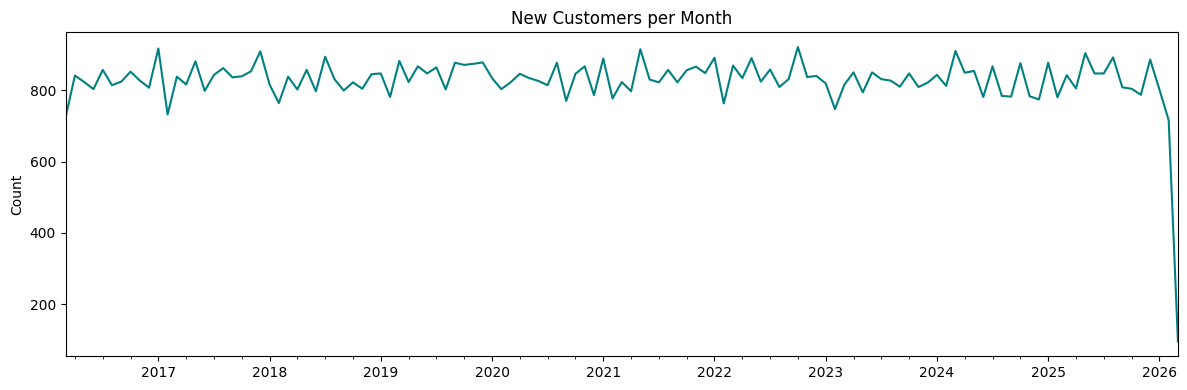

In [25]:
# customer growth over time
monthly = df.groupby(df['created_date'].dt.to_period('M')).size()

plt.figure(figsize=(12, 4))
monthly.plot(color='teal', linewidth=1.5)
plt.title('New Customers per Month')
plt.xlabel('')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

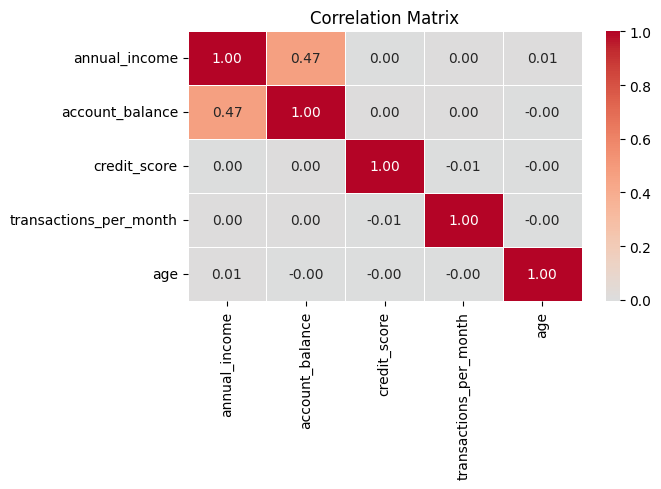

In [26]:
# correlation between all numeric columns
num_cols = ['annual_income', 'account_balance', 'credit_score', 'transactions_per_month', 'age']

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

both banks are basically identical in every metric. the correlation matrix shows most features are independent — no strong relationships between income, balance, credit score, or transactions.

---

## summary

the python analysis confirms what we found in SQL but the charts add more context:

- the segmentation heatmap is probably the most useful visual — clearly shows where the risk is
- scatter plot confirms zero correlation between balance and transactions
- income is heavily right-skewed, most people earn under 20L
- both banks are nearly identical across all metrics
- 84% high-value customers is great but 41% poor credit is not
- ~15% inactive accounts need attention

next: power bi dashboard for interactive exploration